In [1]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [13]:
import os

print("Files available in Kaggle Input:\n")

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

Files available in Kaggle Input:

/kaggle/input/datasets/mansoordaku/ckdisease/kidney_disease.csv


In [14]:
# Load Kidney Disease Dataset

import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/mansoordaku/ckdisease/kidney_disease.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (400, 26)


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [15]:
# Dataset information

print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Columns:
['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  

In [17]:
# Check missing values

print(df.isnull().sum())

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


In [18]:
# Basic Dataset Information

print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape of Dataset: (400, 26)

Column Names:
['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

Data Types:
id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object


In [19]:
# Check Missing Values

missing = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing)

Missing Values in Each Column:
id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


In [20]:
# Check Duplicate Rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [21]:
# Check Target Values

print(df['classification'].value_counts())

classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


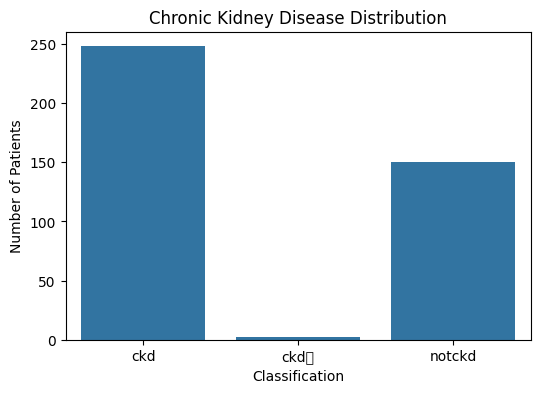

In [22]:
# Target Distribution

plt.figure(figsize=(6,4))

sns.countplot(x='classification', data=df)

plt.title("Chronic Kidney Disease Distribution")
plt.xlabel("Classification")
plt.ylabel("Number of Patients")

plt.show()

In [23]:
# Remove extra spaces from column names

df.columns = df.columns.str.strip()

print(df.columns.tolist())

['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


In [24]:
# Replace common missing-value symbols with NaN

import numpy as np

df = df.replace(['?', '\t?', ' ?', ''], np.nan)

print("Missing values:")
print(df.isnull().sum())

Missing values:
id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                71
wc                106
rc                131
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


In [25]:
# Convert numeric columns to numeric datatype

numeric_columns = [
    'age', 'bp', 'sg', 'al', 'su',
    'bgr', 'bu', 'sc', 'sod', 'pot',
    'hemo', 'pcv', 'wc', 'rc'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv               float64
wc                float64
rc                float64
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object


In [29]:
# Fill missing categorical values with mode

categorical_columns = [
    'rbc', 'pc', 'pcc', 'ba',
    'htn', 'dm', 'cad', 'appet',
    'pe', 'ane'
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [30]:
# Fill missing numerical values with median

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64


In [32]:
# Clean target column

df['classification'] = df['classification'].str.strip()

df['classification'] = df['classification'].replace({
    'ckd': 'ckd',
    'ckd\t': 'ckd',
    'notckd': 'notckd',
    'notckd\t': 'notckd'
})

print(df['classification'].value_counts())

classification
ckd       250
notckd    150
Name: count, dtype: int64


In [34]:
# Step 5: Encode Categorical Variables

from sklearn.preprocessing import LabelEncoder

# Copy dataset
df_ml = df.copy()

# Encode all categorical columns
categorical_columns = df_ml.select_dtypes(include=['object']).columns

label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    label_encoders[col] = le

print("Categorical columns encoded successfully!")

df_ml.head()

Categorical columns encoded successfully!


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,...,44.0,7800.0,5.2,1,4,1,0,0,0,0
1,1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,...,38.0,6000.0,4.8,0,3,1,0,0,0,0
2,2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,...,31.0,7500.0,4.8,0,4,1,1,0,1,0
3,3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,...,32.0,6700.0,3.9,1,3,1,1,1,1,0
4,4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,...,35.0,7300.0,4.6,0,3,1,0,0,0,0


In [35]:
# Separate Features and Target

X = df_ml.drop('classification', axis=1)
y = df_ml['classification']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (400, 25)
Target shape: (400,)


In [36]:
# Split Dataset into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (320, 25)
Testing data: (80, 25)


In [37]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [38]:
# Step 6: Import Machine Learning Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

print("Models imported successfully!")

Models imported successfully!


In [39]:
# Create Models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "SVM": SVC()
}

# Train models

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(name, "trained successfully!")

Logistic Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!
SVM trained successfully!


In [40]:
# Model Evaluation

from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

print("\nModel Accuracy:")
for name, accuracy in results.items():
    print(f"{name}: {accuracy:.4f}")


Model Accuracy:
Logistic Regression: 1.0000
Decision Tree: 1.0000
Random Forest: 0.9875
SVM: 1.0000


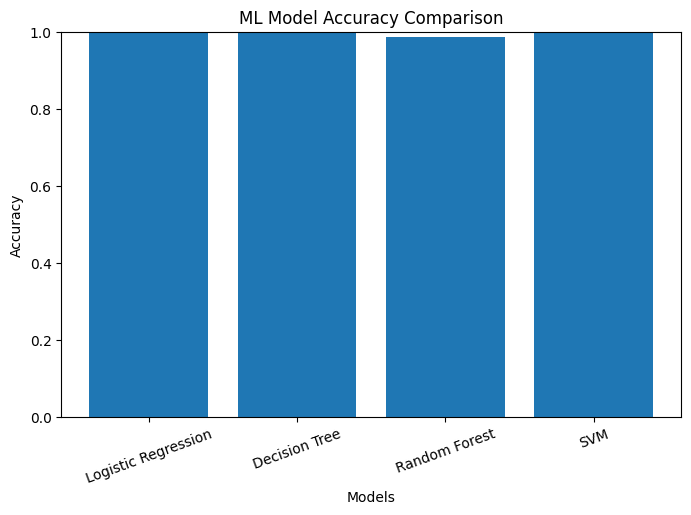

In [41]:
# Compare Model Accuracy

plt.figure(figsize=(8, 5))

plt.bar(results.keys(), results.values())

plt.title("ML Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.show()

In [42]:
# Step 7: Detailed Model Evaluation

from sklearn.metrics import classification_report

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(classification_report(
        y_test,
        y_pred,
        target_names=["Not CKD", "CKD"]
    ))

Logistic Regression
              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        50
         CKD       1.00      1.00      1.00        30

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

Decision Tree
              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        50
         CKD       1.00      1.00      1.00        30

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

Random Forest
              precision    recall  f1-score   support

     Not CKD       0.98      1.00      0.99        50
         CKD       1.00      0.97      0.98        30

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg       0.99   

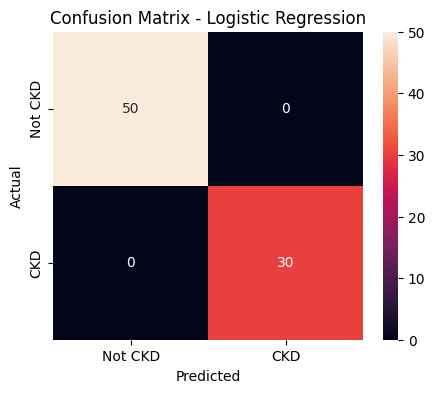

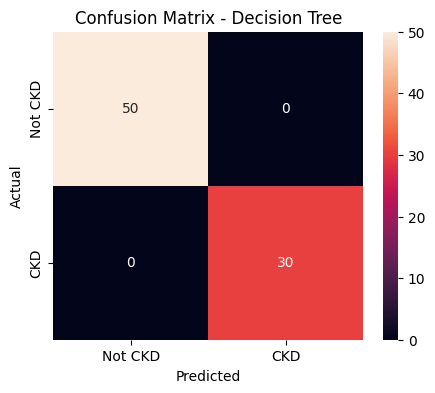

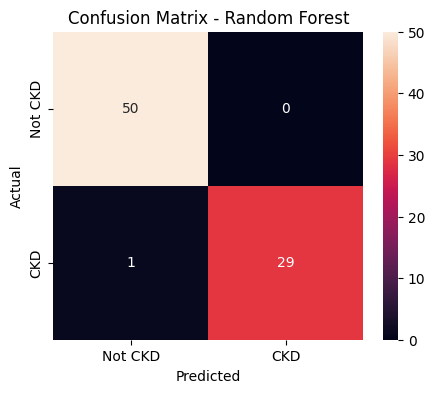

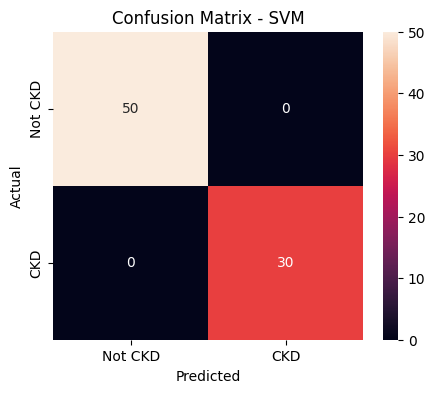

In [43]:
from sklearn.metrics import confusion_matrix

for name, model in models.items():

    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        xticklabels=["Not CKD", "CKD"],
        yticklabels=["Not CKD", "CKD"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [44]:
# Create a comparison table

evaluation_results = []

for name, model in models.items():

    y_pred = model.predict(X_test_scaled)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1 Score": report["1"]["f1-score"]
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0000,1.0,1.000000,1.000000
1,Decision Tree,1.0000,1.0,1.000000,1.000000
3,SVM,1.0000,1.0,1.000000,1.000000
2,Random Forest,0.9875,1.0,0.966667,0.983051


In [45]:
# Step 8: Select Best Model

best_model_name = evaluation_df.loc[
    evaluation_df["F1 Score"].idxmax(), "Model"
]

best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("Best F1 Score:",
      evaluation_df["F1 Score"].max())

Best Model: Logistic Regression
Best F1 Score: 1.0


In [46]:
# Detailed performance of best model

y_pred_best = best_model.predict(X_test_scaled)

print("Best Model:", best_model_name)
print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred_best,
    target_names=["Not CKD", "CKD"]
))

Best Model: Logistic Regression

Classification Report:

              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        50
         CKD       1.00      1.00      1.00        30

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [47]:
# Save Best Model and Scaler

import joblib

joblib.dump(best_model, "/kaggle/working/kidney_disease_model.pkl")
joblib.dump(scaler, "/kaggle/working/kidney_scaler.pkl")

print("Model saved successfully!")
print("Scaler saved successfully!")

Model saved successfully!
Scaler saved successfully!


In [48]:
import os

print(os.listdir("/kaggle/working"))

['kidney_scaler.pkl', 'kidney_disease_model.pkl', '.virtual_documents']


In [49]:
# Load saved model

loaded_model = joblib.load(
    "/kaggle/working/kidney_disease_model.pkl"
)

loaded_scaler = joblib.load(
    "/kaggle/working/kidney_scaler.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [50]:
print(X.columns.tolist())

['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


In [52]:
# New Patient Prediction

sample_patient = {
    'age': 48,
    'bp': 80,
    'sg': 1.020,
    'al': 1,
    'su': 0,
    'rbc': 1,
    'pc': 1,
    'pcc': 0,
    'ba': 0,
    'bgr': 120,
    'bu': 36,
    'sc': 1.2,
    'sod': 138,
    'pot': 4.5,
    'hemo': 14.0,
    'pcv': 42,
    'wc': 8000,
    'rc': 5.2,
    'htn': 0,
    'dm': 0,
    'cad': 0,
    'appet': 1,
    'pe': 0,
    'ane': 0
}

In [53]:
# Convert patient data into DataFrame

patient_df = pd.DataFrame([sample_patient])

print(patient_df)

   age  bp    sg  al  su  rbc  pc  pcc  ba  bgr  ...  hemo  pcv    wc   rc  \
0   48  80  1.02   1   0    1   1    0   0  120  ...  14.0   42  8000  5.2   

   htn  dm  cad  appet  pe  ane  
0    0   0    0      1   0    0  

[1 rows x 24 columns]


In [57]:
# Remove ID before ML

df_ml = df.copy()

if 'id' in df_ml.columns:
    df_ml = df_ml.drop('id', axis=1)

# Encode categorical columns

categorical_columns = df_ml.select_dtypes(include=['object']).columns

label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    label_encoders[col] = le

# Features and target

X = df_ml.drop('classification', axis=1)
y = df_ml['classification']

print("Final features:")
print(X.columns.tolist())
print("\nShape:", X.shape)

Final features:
['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

Shape: (400, 24)


In [62]:
# FINAL TRAINING - ID removed

# Copy cleaned dataset
df_ml = df.copy()

# Remove ID column
if 'id' in df_ml.columns:
    df_ml = df_ml.drop(columns=['id'])

# Encode categorical columns
categorical_columns = df_ml.select_dtypes(include=['object']).columns

label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    label_encoders[col] = le

# Features and target
X = df_ml.drop('classification', axis=1)
y = df_ml['classification']

print("Features:", X.shape)
print(X.columns.tolist())

Features: (400, 24)
['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


In [63]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (320, 24)
Testing: (80, 24)


In [64]:
# Train Models Again

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    results[name] = accuracy_score(y_test, y_pred)

    print(f"{name}: {results[name]:.4f}")

Logistic Regression: 0.9750
Decision Tree: 0.9750
Random Forest: 0.9750
SVM: 0.9875


In [65]:
# Select Best Model

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("Accuracy:", results[best_model_name])

Best Model: SVM
Accuracy: 0.9875


In [66]:
# Save final model and scaler

joblib.dump(best_model, "/kaggle/working/kidney_disease_model.pkl")
joblib.dump(scaler, "/kaggle/working/kidney_scaler.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [67]:
# Load FINAL model and scaler

loaded_model = joblib.load(
    "/kaggle/working/kidney_disease_model.pkl"
)

loaded_scaler = joblib.load(
    "/kaggle/working/kidney_scaler.pkl"
)

print("Final model and scaler loaded!")

Final model and scaler loaded!


In [68]:
# Final Patient Prediction

# Make sure patient data has exactly the same features as X
patient_df = patient_df.reindex(columns=X.columns)

# Convert values to numeric
patient_df = patient_df.apply(pd.to_numeric, errors='coerce')

# Check missing values
print("Missing values:", patient_df.isnull().sum().sum())

# Scale patient data
patient_scaled = loaded_scaler.transform(patient_df)

# Predict
prediction = loaded_model.predict(patient_scaled)

# Convert prediction back to original class
predicted_class = label_encoders['classification'].inverse_transform(prediction)

print("\nRaw Prediction:", prediction)
print("Final Prediction:", predicted_class[0])

if predicted_class[0] == "ckd":
    print("\n⚠️ Prediction: CKD")
else:
    print("\n✅ Prediction: Not CKD")

Missing values: 0

Raw Prediction: [0]
Final Prediction: ckd

⚠️ Prediction: CKD


In [69]:
!pip install -q gradio

In [70]:
import gradio as gr

print("Gradio loaded successfully!")

Gradio loaded successfully!


In [73]:
def predict_kidney(
    age, bp, sg, al, su,
    rbc, pc, pcc, ba,
    bgr, bu, sc, sod, pot,
    hemo, pcv, wc, rc,
    htn, dm, cad, appet, pe, ane
):
    
    # Create patient dataframe
    patient = pd.DataFrame([{
        'age': age,
        'bp': bp,
        'sg': sg,
        'al': al,
        'su': su,
        'rbc': rbc,
        'pc': pc,
        'pcc': pcc,
        'ba': ba,
        'bgr': bgr,
        'bu': bu,
        'sc': sc,
        'sod': sod,
        'pot': pot,
        'hemo': hemo,
        'pcv': pcv,
        'wc': wc,
        'rc': rc,
        'htn': htn,
        'dm': dm,
        'cad': cad,
        'appet': appet,
        'pe': pe,
        'ane': ane
    }])

    # Same feature order as training
    patient = patient.reindex(columns=X.columns)

    # Convert to numeric
    patient = patient.apply(pd.to_numeric, errors='coerce')

    # Scale
    patient_scaled = loaded_scaler.transform(patient)

    # Prediction
    prediction = loaded_model.predict(patient_scaled)

    # Convert label
    result = label_encoders['classification'].inverse_transform(prediction)[0]

    if result == 'ckd':
        return "⚠️ Prediction: CKD"
    else:
        return "✅ Prediction: Not CKD"

In [74]:
# Create Interactive UI

with gr.Blocks() as demo:

    gr.Markdown("# 🩺 Chronic Kidney Disease Prediction")
    gr.Markdown(
        "Enter patient information to get an ML-based prediction."
    )

    with gr.Row():
        age = gr.Number(label="Age", value=48)
        bp = gr.Number(label="Blood Pressure", value=80)
        sg = gr.Number(label="Specific Gravity", value=1.020)
        al = gr.Number(label="Albumin", value=1)
        su = gr.Number(label="Sugar", value=0)

    with gr.Row():
        rbc = gr.Number(label="Red Blood Cells", value=1)
        pc = gr.Number(label="Pus Cell", value=1)
        pcc = gr.Number(label="Pus Cell Clumps", value=0)
        ba = gr.Number(label="Bacteria", value=0)

    with gr.Row():
        bgr = gr.Number(label="Blood Glucose", value=120)
        bu = gr.Number(label="Blood Urea", value=36)
        sc = gr.Number(label="Serum Creatinine", value=1.2)
        sod = gr.Number(label="Sodium", value=138)
        pot = gr.Number(label="Potassium", value=4.5)

    with gr.Row():
        hemo = gr.Number(label="Hemoglobin", value=14)
        pcv = gr.Number(label="Packed Cell Volume", value=42)
        wc = gr.Number(label="White Blood Cell Count", value=8000)
        rc = gr.Number(label="Red Blood Cell Count", value=5.2)

    with gr.Row():
        htn = gr.Number(label="Hypertension", value=0)
        dm = gr.Number(label="Diabetes Mellitus", value=0)
        cad = gr.Number(label="Coronary Artery Disease", value=0)
        appet = gr.Number(label="Appetite", value=1)
        pe = gr.Number(label="Pedal Edema", value=0)
        ane = gr.Number(label="Anemia", value=0)

    predict_button = gr.Button("🔍 Predict")

    output = gr.Textbox(label="Prediction Result")

    predict_button.click(
        fn=predict_kidney,
        inputs=[
            age, bp, sg, al, su,
            rbc, pc, pcc, ba,
            bgr, bu, sc, sod, pot,
            hemo, pcv, wc, rc,
            htn, dm, cad, appet, pe, ane
        ],
        outputs=output
    )

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).


Could not create share link. Missing file: /root/.cache/huggingface/gradio/frpc/frpc_linux_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_linux_amd64
2. Rename the downloaded file to: frpc_linux_amd64_v0.3
3. Move the file to this location: /root/.cache/huggingface/gradio/frpc


In [75]:
def predict_kidney(
    age, bp, sg, al, su,
    rbc, pc, pcc, ba,
    bgr, bu, sc, sod, pot,
    hemo, pcv, wc, rc,
    htn, dm, cad, appet, pe, ane
):
    
    patient = pd.DataFrame([{
        'age': age,
        'bp': bp,
        'sg': sg,
        'al': al,
        'su': su,
        'rbc': rbc,
        'pc': pc,
        'pcc': pcc,
        'ba': ba,
        'bgr': bgr,
        'bu': bu,
        'sc': sc,
        'sod': sod,
        'pot': pot,
        'hemo': hemo,
        'pcv': pcv,
        'wc': wc,
        'rc': rc,
        'htn': htn,
        'dm': dm,
        'cad': cad,
        'appet': appet,
        'pe': pe,
        'ane': ane
    }])

    patient = patient.reindex(columns=X.columns)

    patient = patient.apply(pd.to_numeric, errors='coerce')

    patient_scaled = loaded_scaler.transform(patient)

    prediction = loaded_model.predict(patient_scaled)

    result = label_encoders['classification'].inverse_transform(
        prediction
    )[0]

    if result == "ckd":
        return "⚠️ CKD Prediction"
    else:
        return "✅ Not CKD Prediction"

In [76]:
with gr.Blocks(title="Kidney Disease Prediction") as demo:

    gr.Markdown(
        """
        # 🩺 Kidney Disease Prediction System
        
        ### Machine Learning Based Prediction
        
        Enter the patient's medical parameters below.
        """
    )

    with gr.Row():
        age = gr.Number(label="Age", value=48)
        bp = gr.Number(label="Blood Pressure", value=80)
        sg = gr.Number(label="Specific Gravity", value=1.020)

    with gr.Row():
        al = gr.Number(label="Albumin", value=1)
        su = gr.Number(label="Sugar", value=0)
        bgr = gr.Number(label="Blood Glucose", value=120)

    with gr.Row():
        bu = gr.Number(label="Blood Urea", value=36)
        sc = gr.Number(label="Serum Creatinine", value=1.2)
        sod = gr.Number(label="Sodium", value=138)

    with gr.Row():
        pot = gr.Number(label="Potassium", value=4.5)
        hemo = gr.Number(label="Hemoglobin", value=14)
        pcv = gr.Number(label="Packed Cell Volume", value=42)

    with gr.Row():
        wc = gr.Number(label="White Blood Cell Count", value=8000)
        rc = gr.Number(label="Red Blood Cell Count", value=5.2)

    gr.Markdown("### Medical Indicators")

    with gr.Row():
        rbc = gr.Dropdown(
            choices=[0, 1],
            value=1,
            label="Red Blood Cells"
        )

        pc = gr.Dropdown(
            choices=[0, 1],
            value=1,
            label="Pus Cell"
        )

        pcc = gr.Dropdown(
            choices=[0, 1],
            value=0,
            label="Pus Cell Clumps"
        )

        ba = gr.Dropdown(
            choices=[0, 1],
            value=0,
            label="Bacteria"
        )

    with gr.Row():
        htn = gr.Dropdown(
            choices=[0, 1],
            value=0,
            label="Hypertension"
        )

        dm = gr.Dropdown(
            choices=[0, 1],
            value=0,
            label="Diabetes Mellitus"
        )

        cad = gr.Dropdown(
            choices=[0, 1],
            value=0,
            label="Coronary Artery Disease"
        )

        appet = gr.Dropdown(
            choices=[0, 1],
            value=1,
            label="Appetite"
        )

        pe = gr.Dropdown(
            choices=[0, 1],
            value=0,
            label="Pedal Edema"
        )

        ane = gr.Dropdown(
            choices=[0, 1],
            value=0,
            label="Anemia"
        )

    predict_button = gr.Button(
        "🔍 Predict Kidney Disease"
    )

    output = gr.Textbox(
        label="Prediction Result"
    )

    predict_button.click(
        predict_kidney,
        inputs=[
            age, bp, sg, al, su,
            rbc, pc, pcc, ba,
            bgr, bu, sc, sod, pot,
            hemo, pcv, wc, rc,
            htn, dm, cad, appet, pe, ane
        ],
        outputs=output
    )

    gr.Markdown(
        """
        **Disclaimer:** This project is for educational purposes only 
        and should not be used as a medical diagnosis.
        """
    )

demo.launch()

* Running on local URL:  http://127.0.0.1:7861
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).


Could not create share link. Missing file: /root/.cache/huggingface/gradio/frpc/frpc_linux_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_linux_amd64
2. Rename the downloaded file to: frpc_linux_amd64_v0.3
3. Move the file to this location: /root/.cache/huggingface/gradio/frpc


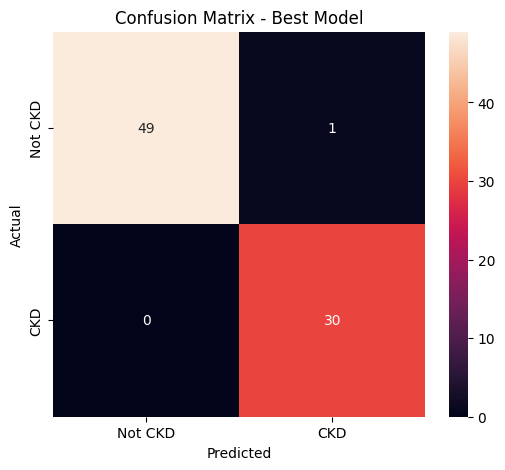

In [78]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

y_pred_best = loaded_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Not CKD', 'CKD'],
    yticklabels=['Not CKD', 'CKD']
)

plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

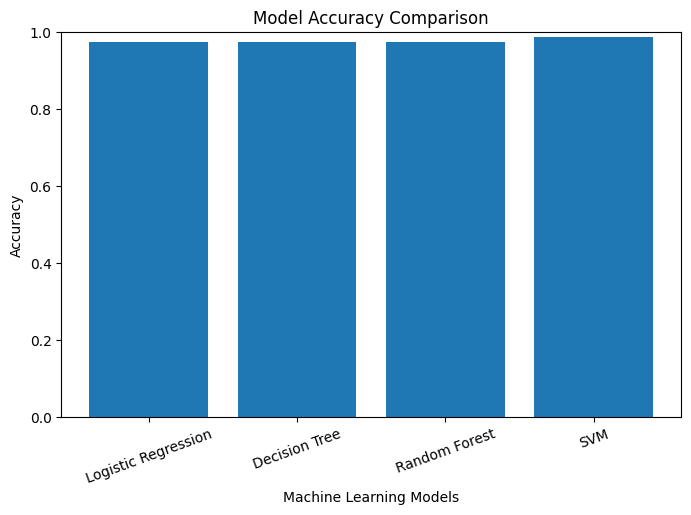

In [80]:
# Model Accuracy Comparison

plt.figure(figsize=(8, 5))

plt.bar(
    results.keys(),
    results.values()
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.show()

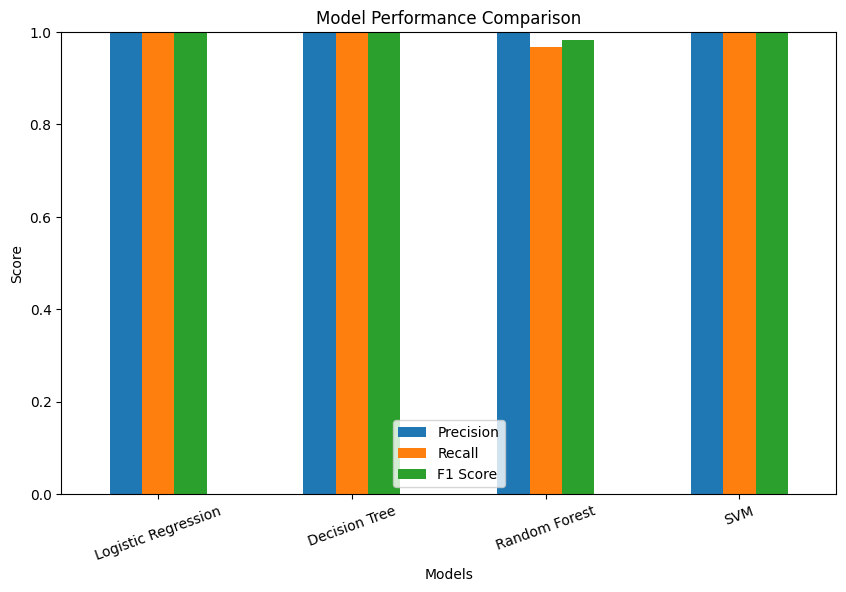

In [82]:
# Precision, Recall and F1 Score

metrics_df = evaluation_df.set_index("Model")[
    ["Precision", "Recall", "F1 Score"]
]

metrics_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")

plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.show()

In [84]:
# Feature Importance

if hasattr(loaded_model, "feature_importances_"):

    importance = pd.Series(
        loaded_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(10, 7))

    importance.head(15).plot(
        kind="barh"
    )

    plt.title("Top 15 Important Features")
    plt.xlabel("Importance")

    plt.gca().invert_yaxis()

    plt.show()

else:
    print("Feature importance is not available for the selected model.")

Feature importance is not available for the selected model.


In [86]:
# ROC Curve and AUC

from sklearn.metrics import roc_curve, roc_auc_score

# Get prediction probabilities
if hasattr(loaded_model, "predict_proba"):
    y_score = loaded_model.predict_proba(X_test_scaled)[:, 1]
else:
    y_score = loaded_model.decision_function(X_test_scaled)

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_score)

# AUC
auc_score = roc_auc_score(y_test, y_score)

print("AUC Score:", round(auc_score, 4))

AUC Score: 1.0


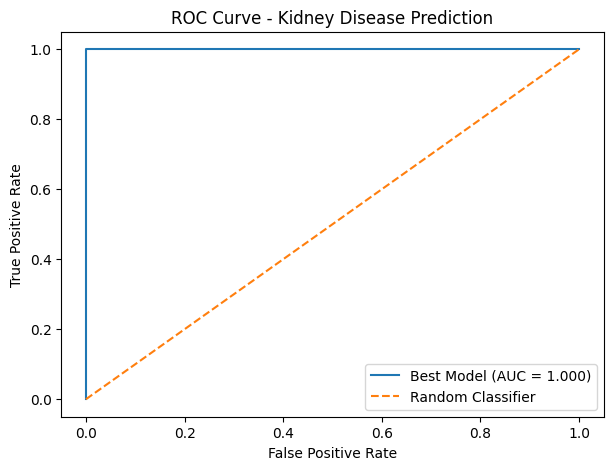

In [88]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Best Model (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Kidney Disease Prediction")

plt.legend()
plt.show()

In [90]:
# Final Model Performance

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = loaded_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("========== FINAL MODEL PERFORMANCE ==========")
print("Best Model :", best_model_name)
print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1 Score   : {f1:.4f}")
print(f"AUC Score  : {auc_score:.4f}")

========== FINAL MODEL PERFORMANCE ==========
Best Model : SVM
Accuracy   : 0.9875
Precision  : 0.9677
Recall     : 1.0000
F1 Score   : 0.9836
AUC Score  : 1.0000


In [91]:
# Final Results Table

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        auc_score
    ]
})

final_results

,Metric,Score
0,Accuracy,0.987500
1,Precision,0.967742
2,Recall,1.000000
3,F1 Score,0.983607
4,AUC,1.000000


## Conclusion

In this project, machine learning techniques were used to predict
Chronic Kidney Disease using patient-related clinical features.

Multiple machine learning algorithms were trained and evaluated,
including Logistic Regression, Decision Tree, Random Forest, and SVM.

The models were compared using Accuracy, Precision, Recall, F1 Score,
and ROC-AUC.

The best-performing model was selected based on the evaluation results
and was used to create a patient prediction system.

This project demonstrates how machine learning can be applied to
healthcare-related classification problems.

### Disclaimer
This project is developed for educational and research purposes only.
The predictions should not be considered a medical diagnosis.

## Limitations

- The model is trained on a relatively small dataset.
- The results depend on the quality and distribution of the dataset.
- The model has not been clinically validated on real-world hospital data.
- Performance on external datasets may differ from the test-set results.
- This system is intended for educational purposes and not for medical diagnosis.

## Future Scope

- Test the model on larger and more diverse datasets.
- Perform external validation using independent patient data.
- Apply advanced feature selection and hyperparameter tuning.
- Compare additional machine learning and deep learning models.
- Develop a secure web or mobile application for educational use.
- Improve the user interface and prediction reporting.

In [93]:
# Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Best Cross-Validation F1 Score:
0.9916630481980027


In [96]:
# Best Tuned Random Forest

tuned_model = grid_search.best_estimator_

y_pred_tuned = tuned_model.predict(X_test_scaled)

print("Tuned Random Forest Performance:")
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=["Not CKD", "CKD"]
))

Tuned Random Forest Performance:
              precision    recall  f1-score   support

     Not CKD       0.96      1.00      0.98        50
         CKD       1.00      0.93      0.97        30

    accuracy                           0.97        80
   macro avg       0.98      0.97      0.97        80
weighted avg       0.98      0.97      0.97        80



In [97]:
# Compare Default and Tuned Random Forest

default_rf = models["Random Forest"]

default_pred = default_rf.predict(X_test_scaled)

default_f1 = f1_score(y_test, default_pred)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("Default Random Forest F1 Score:", round(default_f1, 4))
print("Tuned Random Forest F1 Score:", round(tuned_f1, 4))

Default Random Forest F1 Score: 0.9655
Tuned Random Forest F1 Score: 0.9655


In [98]:
# Save Final Model

final_model = best_model

joblib.dump(
    final_model,
    "/kaggle/working/final_kidney_disease_model.pkl"
)

joblib.dump(
    loaded_scaler,
    "/kaggle/working/final_kidney_scaler.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [99]:
import os

print(os.listdir("/kaggle/working"))

['kidney_scaler.pkl', 'kidney_disease_model.pkl', 'final_kidney_disease_model.pkl', '.virtual_documents', 'final_kidney_scaler.pkl']


In [105]:
print("Final model:", type(final_model).__name__)

Final model: SVC


In [106]:
# Feature Importance using Permutation Importance

from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    final_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_importance.importances_mean
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
   Feature  Importance
2       sg    0.107509
14    hemo    0.068876
15     pcv    0.057702
3       al    0.046799
18     htn    0.036925
19      dm    0.031605
8       ba    0.029675
17      rc    0.022654
21   appet    0.018867
20     cad    0.017222
22      pe    0.015648
6       pc    0.012027
10      bu    0.010503
4       su    0.008694
23     ane    0.006943
7      pcc    0.006888
5      rbc    0.005191
11      sc    0.003609
13     pot    0.000000
1       bp   -0.001022
12     sod   -0.004753
16      wc   -0.004808
0      age   -0.004918
9      bgr   -0.006446


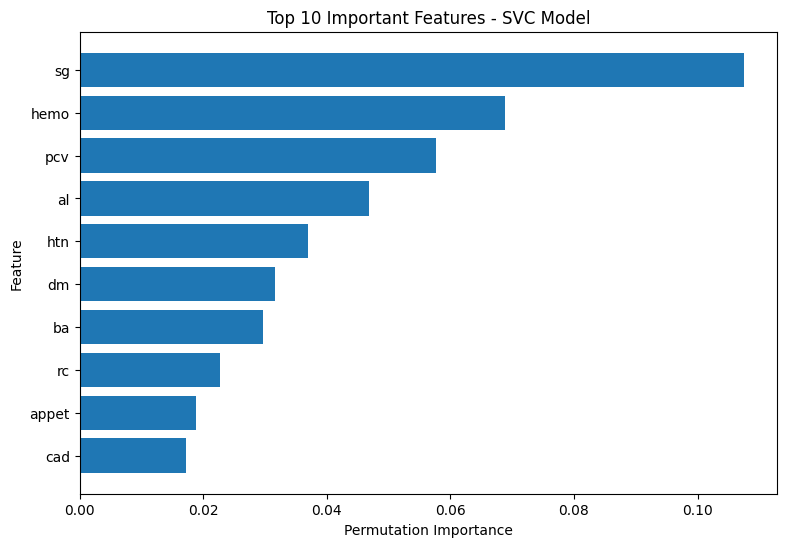

In [107]:
# Top 10 Important Features

top_features = feature_importance.head(10)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features - SVC Model")

plt.show()

# 🩺 Chronic Kidney Disease Prediction Using Machine Learning

## Project Overview

Chronic Kidney Disease (CKD) is a long-term condition that can affect
kidney function. Early identification of potential CKD cases can be
useful for further medical evaluation.

In this project, machine learning classification algorithms are used
to predict whether a patient is likely to have Chronic Kidney Disease
based on clinical features.

The project includes data preprocessing, exploratory data analysis,
machine learning model training, model evaluation, feature importance
analysis, and an interactive prediction interface.

### Machine Learning Models

- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Classifier (SVC)

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

### Best Model

The Support Vector Classifier (SVC) achieved the best performance
among the evaluated models on the test dataset.

> **Disclaimer:** This project is for educational purposes only.
> The predictions should not be considered a medical diagnosis.